# Getting Started with DNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


**Task 1** Please check the number of training and testing example.  
**Task 2** How many labels do we have?  
**Task 3** Check the image size and plot few examples  

Number of training examples: 60000
Number of testing examples: 10000
Number of labels: 10
Image size: (28, 28)


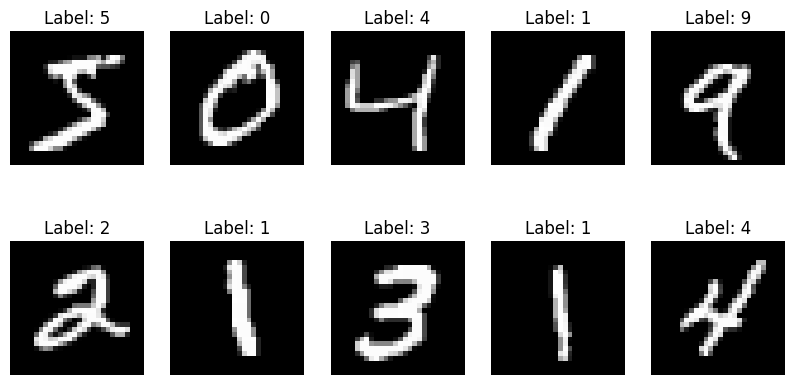

In [3]:
n_train = train_images.shape[0]
n_test = test_images.shape[0]
print(f"Number of training examples: {n_train}")
print(f"Number of testing examples: {n_test}")

n_classes = len(np.unique(train_labels))
print(f"Number of labels: {n_classes}")

image_shape = train_images.shape[1:]
print(f"Image size: {image_shape}")

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

## Network Architecture

In [4]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Input(shape=(28 * 28,)))
network.add(layers.Dense(512, activation="relu"))
network.add(layers.Dense(10, activation="softmax"))

## Network Training

In [5]:
network.compile(
    optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"]
)

## Data Preparation

In [6]:
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

In [7]:
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

## Fit the Model

In [8]:
network.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9237 - loss: 0.2659
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9683 - loss: 0.1076
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9785 - loss: 0.0712
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0513
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0385


## Network Evaluation

In [9]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0644
Test accuracy: 0.9793000221252441
